In [1]:
import numpy as np
import pandas as pd
import os

In [2]:
data = pd.read_csv(r"/Users/zulidobariya/Desktop/6th_sem/ADML/LargeMovieDataset.csv")

In [3]:
data.head()

,MovieID,Title,Genre,Rating,Popularity
0,1,Chaos Theory 1,Horror,3.5,93
1,2,Mystic Falls 2,Sci-Fi,3.4,34
2,3,The Legend 3,Horror,4.2,74
3,4,Chaos Theory 4,Documentary,2.2,59
4,5,Infinite Horizon 5,Sci-Fi,3.7,77


In [4]:
data.tail()

,MovieID,Title,Genre,Rating,Popularity
9995,9996,Mystic Falls 9996,Horror,4.7,30
9996,9997,Chaos Theory 9997,Sci-Fi,4.3,76
9997,9998,Storm Riders 9998,Fantasy,3.7,77
9998,9999,Fearless Fighter 9999,Comedy,4.2,34
9999,10000,Mystic Falls 10000,Sci-Fi,4.1,11


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MovieID     10000 non-null  int64  
 1   Title       10000 non-null  object 
 2   Genre       10000 non-null  object 
 3   Rating      10000 non-null  float64
 4   Popularity  10000 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 390.8+ KB


In [6]:
data.describe()

,MovieID,Rating,Popularity
count,10000.00000,10000.000000,10000.000000
mean,5000.50000,3.006050,50.729500
std,2886.89568,1.148119,28.636573
min,1.00000,1.000000,1.000000
25%,2500.75000,2.000000,26.000000
50%,5000.50000,3.000000,51.000000
75%,7500.25000,4.000000,76.000000
max,10000.00000,5.000000,100.000000


In [7]:
data.isnull().sum()

MovieID       0
Title         0
Genre         0
Rating        0
Popularity    0
dtype: int64

In [8]:
data.columns

Index(['MovieID', 'Title', 'Genre', 'Rating', 'Popularity'], dtype='object')

In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# OneHotEncoding

In [10]:
encoder = OneHotEncoder(sparse_output=False, drop='first')
genre_encoded = encoder.fit_transform(data[['Genre']])

In [11]:
genre_encoded_df = pd.DataFrame(genre_encoded, columns=encoder.get_feature_names_out(['Genre']))

In [12]:
data_encoded = pd.concat([data.drop(columns=['Genre', 'Title']), genre_encoded_df], axis=1)

In [13]:
data_encoded

,MovieID,Rating,Popularity,Genre_Adventure,Genre_Comedy,Genre_Documentary,Genre_Drama,Genre_Fantasy,Genre_Horror,Genre_Romance,Genre_Sci-Fi,Genre_Thriller
0,1,3.5,93,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2,3.4,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,3,4.2,74,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,4,2.2,59,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,3.7,77,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,4.7,30,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9996,9997,4.3,76,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9997,9998,3.7,77,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9998,9999,4.2,34,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# StandardScaler

In [14]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_encoded)

# KMeans

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [18]:
wcss = []
for i in range(1, 5):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

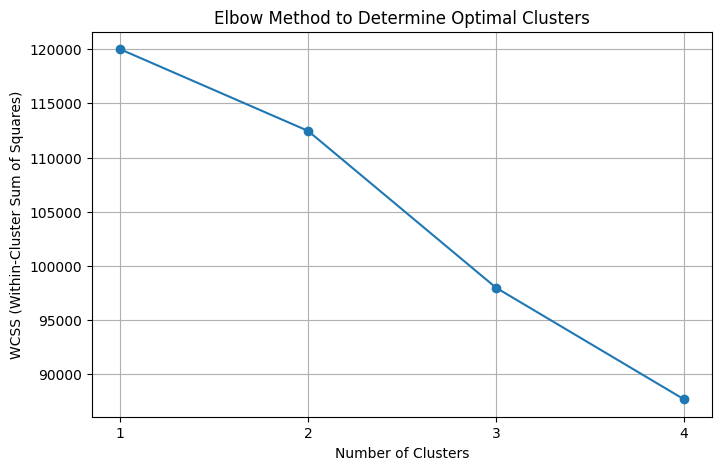

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, wcss, marker='o')
plt.title('Elbow Method to Determine Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(cluster_range)
plt.grid()
plt.show()

In [25]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
data['Cluster'] = kmeans.fit_predict(data_scaled)

In [26]:
def recommend_movies(movie_title, data_with_clusters, num_recommendations=5):
    """
    Recommend movies similar to the input movie based on clustering.

    Parameters:
    movie_title (str): The title of the movie for which recommendations are needed.
    data_with_clusters (DataFrame): The dataset with cluster assignments.
    num_recommendations (int): Number of recommendations to return (default is 5).

    Returns:
    List of recommended movie titles.
    """
    try:
        movie_cluster = data_with_clusters.loc[data_with_clusters['Title'] == movie_title, 'Cluster'].values[0]

        similar_movies = data_with_clusters[
            (data_with_clusters['Cluster'] == movie_cluster) & (data_with_clusters['Title'] != movie_title)
        ]

        recommendations = similar_movies['Title'].head(num_recommendations).tolist()

        if not recommendations:
            return ["No similar movies found in this cluster."]

        return recommendations
    except IndexError:
        return ["Movie not found in the dataset."]


In [33]:
recommendations = recommend_movies("Chaos Theory 1", data)
print(recommendations)

['The Legend 3', 'Mystic Falls 7', 'Final Stand 12', 'Dream Catcher 16', 'Hidden Truth 59']
